# Kniffel-Labor

Alles an einem Ort: Regeln einstellen, optimale Strategie berechnen, simulieren, Spielsituationen bewerten und Gewichte für die Heuristik vergleichen.

**Ablauf:** Zelle 1 (Einstellungen) anpassen und von oben nach unten ausführen.

- Die optimale Strategie wird je Regelvariante einmal berechnet (10–40 s) und als `kniffel_V_*.npy` gespeichert. Diese Dateien landen nicht in Git.
- Die übrigen Zellen laufen in Sekunden.

**Grundregeln wie in deinem Code:**

- Oben: Einser bis Sechser, Bonus ab 63.
- Unten: Ein Paar, Zwei Paare, Dreier- und Viererpasch (nur die Pasch-Würfel), Full House 30, kleine Straße 25, große Straße 40, Kniffel 50, Chance.
- Jeder weitere Kniffel bringt +50 und wird zusätzlich in ein anderes Feld eingetragen.

**Joker (Hausregel mit deinem Freund):** Nach dem dritten Wurf darf man einen Joker einsetzen, mehrere auch in derselben Runde:

- *Neustart*: den ganzen Wurf ignorieren und die Runde neu würfeln (wieder 3 Würfe).
- *Einzelwurf*: einen einzelnen Würfel noch einmal würfeln.

## 1. Einstellungen

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kniffel_regeln import Regeln, loese, FIELDS

# ---- Regeln -----------------------------------------------------------------
BONUS      = 37      # Bonus oben ab 63 (deine Hausregel 37, Standard 35)
JOKER      = 2       # Joker pro Spiel (0 = aus)
NEUSTART   = True    # Joker-Art: ganzen Wurf ignorieren, Runde neu würfeln
EINZELWURF = True    # Joker-Art: einen Würfel noch einmal würfeln
# -----------------------------------------------------------------------------

R = Regeln(bonus=BONUS, joker=JOKER, neustart=NEUSTART, einzelwurf=EINZELWURF)
S = loese(R)
print(f"Regeln: {R}")
print(f"Erwarteter Punktestand bei optimalem Spiel: {S.erwartung():.2f}")

Regeln: Regeln(bonus=37, joker=2, neustart=True, einzelwurf=True, kniffel_extra=50)


Erwarteter Punktestand bei optimalem Spiel: 308.94


## 2. Simulation: Verteilung und Statistik je Feld

200,000 Spiele: Mittel 308.85, Median 297, Streuung 49.6, 5 %/95 %: 235/398, Maximum 618
Joker pro Spiel: Neustart 1.33, Einzelwurf 0.66


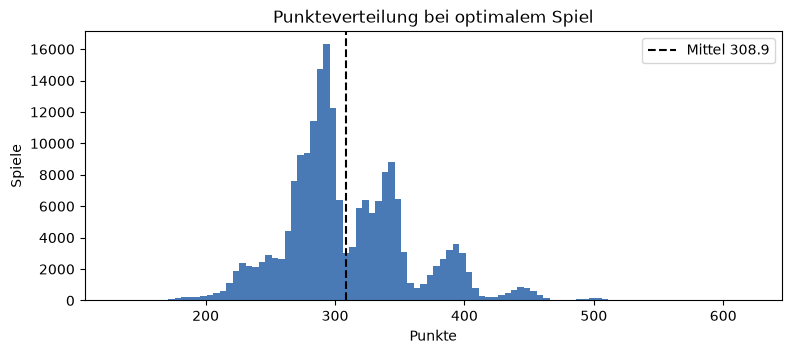

,Ø Punkte,gestrichen (0)
Einser,2.37,7.4%
Zweier,5.79,1.4%
Dreier,9.38,0.5%
Vierer,12.91,0.2%
Fünfer,16.38,0.2%
Sechser,20.34,0.2%
Ein Paar,11.26,0.1%
Zwei Paare,19.18,1.4%
Dreierpasch,15.94,3.0%
Viererpasch,14.25,24.3%


In [2]:
N = 200_000
out = S.simuliere(N, seed=1)
tot = out[:, 0]
print(f"{N:,} Spiele: Mittel {tot.mean():.2f}, Median {np.median(tot):.0f}, Streuung {tot.std():.1f}, "
      f"5 %/95 %: {np.percentile(tot, 5):.0f}/{np.percentile(tot, 95):.0f}, Maximum {tot.max():.0f}")
if R.joker:
    print(f"Joker pro Spiel: Neustart {out[:, 1].mean():.2f}, Einzelwurf {out[:, 2].mean():.2f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.hist(tot, bins=np.arange(tot.min(), tot.max() + 5, 5), color="#4a7ab5")
ax.axvline(tot.mean(), color="k", ls="--", label=f"Mittel {tot.mean():.1f}")
ax.set(xlabel="Punkte", ylabel="Spiele", title="Punkteverteilung bei optimalem Spiel")
ax.legend()
plt.show()

felder = pd.DataFrame({
    "Ø Punkte": out[:, 3:18].mean(axis=0),
    "gestrichen (0)": (out[:, 3:18] == 0).mean(axis=0),
}, index=FIELDS)
felder.loc["Bonus"] = [out[:, 18].mean(), (out[:, 18] == 0).mean()]
felder.loc["Extra-Kniffel"] = [out[:, 19].mean(), np.nan]
felder.style.format({"Ø Punkte": "{:.2f}", "gestrichen (0)": "{:.1%}"})

## 3. Regelvarianten vergleichen

Was bringen die Joker, und was macht der Bonus aus? Neue Varianten werden beim ersten Mal berechnet, danach kommen sie aus dem Cache.

In [3]:
varianten = {
    "Bonus 35, ohne Joker":            Regeln(bonus=35),
    "Bonus 37, ohne Joker":            Regeln(bonus=37),
    "Bonus 37, 1 Joker":               Regeln(bonus=37, joker=1),
    "Bonus 37, 2 Joker nur Neustart":  Regeln(bonus=37, joker=2, neustart=True, einzelwurf=False),
    "Bonus 37, 2 Joker nur Einzelwurf": Regeln(bonus=37, joker=2, neustart=False, einzelwurf=True),
    "Bonus 37, 2 Joker (beide Arten)": Regeln(bonus=37, joker=2),
}
pd.DataFrame({"Erwartungswert": {name: loese(r, quiet=True).erwartung() for name, r in varianten.items()}}).round(2)

,Erwartungswert
"Bonus 35, ohne Joker",287.24
"Bonus 37, ohne Joker",288.90
"Bonus 37, 1 Joker",299.50
"Bonus 37, 2 Joker nur Neustart",307.32
"Bonus 37, 2 Joker nur Einzelwurf",303.73
"Bonus 37, 2 Joker (beide Arten)",308.94


## 4. Berater: Was soll ich hier tun?

- `wurf`: die fünf Würfel.
- `noch`: noch mögliche Würfe in dieser Runde (2 nach dem ersten, 1 nach dem zweiten, 0 = nach dem dritten Wurf, also eintragen oder Joker).
- `belegt`: bereits gefüllte Felder.
- `oben`: Punkte oben bisher.
- `joker`: verbleibende Joker (`None` = alle).

Angezeigt werden die erwarteten Punkte bis Spielende und der Abstand zur besten Wahl.

In [4]:
def berate(wurf, noch=0, belegt=(), oben=0, kniffel50=False, joker=None, top=8):
    rows = S.rat(wurf, noch=noch, belegt=belegt, oben=oben, kniffel50=kniffel50, joker=joker, top=top)
    best = rows[0][1]
    return pd.DataFrame([(n, v, v - best) for n, v in rows], columns=["Möglichkeit", "erwartete Punkte", "Abstand"]).round(2)

berate([2, 2, 3, 3, 3], noch=2)        # erster Wurf 22333 am Spielbeginn

,Möglichkeit,erwartete Punkte,Abstand
0,behalten 333,312.14,0.00
1,behalten 2333,309.54,-2.60
2,behalten 22333,307.86,-4.28
3,behalten 33,306.52,-5.62
4,behalten 22,305.98,-6.16
5,behalten (alles neu),305.45,-6.69
6,behalten 3,305.44,-6.70
7,behalten 233,305.29,-6.85


In [5]:
# Spielende-Situation: nur noch Kniffel und Chance offen, 1 Joker übrig, Wurf 1-1-1-1-3
alle = set(FIELDS)
berate([1, 1, 1, 1, 3], noch=0, belegt=alle - {"Kniffel", "Chance"}, oben=63, joker=min(1, R.joker))

,Möglichkeit,erwartete Punkte,Abstand
0,Joker: eine 3 neu würfeln,31.81,0.00
1,Joker: Neustart,27.29,-4.52
2,Kniffel (0),25.02,-6.79
3,Joker: eine 1 neu würfeln,23.33,-8.48
4,Chance (7),12.97,-18.84


## 5. Full House früh eintragen?

Nach dem letzten Wurf sofort eintragen, oder lieber anders verwenden?

In [6]:
for wurf in ([2, 2, 3, 3, 3], [5, 5, 6, 6, 6], [1, 1, 1, 2, 2]):
    display(berate(wurf, noch=0, top=4).assign(Wurf="".join(map(str, wurf))))
offen = S.erwartung() - S.wert(belegt=["Full House"])
print(f"Ein offenes Full House ist am Spielbeginn im Schnitt noch {offen:.2f} Punkte wert.")

,Möglichkeit,erwartete Punkte,Abstand,Wurf
0,Full House (30),307.86,0.00,22333
1,Dreier (9),303.83,-4.03,22333
2,Joker: Neustart,299.50,-8.36,22333
3,Zweier (4),297.84,-10.01,22333


,Möglichkeit,erwartete Punkte,Abstand,Wurf
0,Full House (30),307.86,0.00,55666
1,Zwei Paare (22),306.52,-1.33,55666
2,Chance (28),306.44,-1.42,55666
3,Dreierpasch (18),305.92,-1.93,55666


,Möglichkeit,erwartete Punkte,Abstand,Wurf
0,Full House (30),307.86,0.00,11122
1,Einser (3),302.74,-5.12,11122
2,Joker: Neustart,299.50,-8.36,11122
3,Zweier (4),297.84,-10.01,11122


Ein offenes Full House ist am Spielbeginn im Schnitt noch 31.08 Punkte wert.


## 6. Bestenliste der Heuristik-Gewichte

Deine Heuristik bewertet je freies Feld mit `Punkte² / Maximalpunkte × Gewicht`. Alle Einträge werden mit denselben 200.000 Würfelfolgen getestet.

Die Liste ist nach Joker-Anzahl getrennt. Mit Jokern entscheidet die Heuristik so: Einzelwurf, wenn das erwartete Potenzial dadurch um mehr als den Anteil `einzel` steigt; sonst Neustart, wenn das beste Potenzial unter `schwelle` liegt. Optimal wären 288,90 (ohne Joker) bzw. 308,94 (2 Joker).

In [7]:
import kniffel_bestenliste as B
B.show()

Bestenliste (200,000 Spiele, gleiche Würfel für alle)

Ohne Joker (optimal wären 288.90):
 #  Name                           Mittel  Median  Phasen  Abstand zu optimal
 1  optimiert, 3 Phasen            274.39     273       3   -14.51
 2  optimiert, 1 Phase             272.06     271       1   -16.84
 3  init() in numba-Datei          253.95     243       1   -34.95
 4  Paul 2024 (simulate_numba)     253.87     243       1   -35.03
 5  alle 1                         247.88     239       1   -41.02

Mit 2 Joker(n) (optimal wären 308.94):
 #  Name                           Mittel  Median  Phasen  Abstand zu optimal
 1  optimiert, 3 Phasen, 2 Joker   292.27     287       3   -16.67
 2  Paul 2024 + 2 Joker (Standard) 261.23     249       1   -47.71


In [8]:
# Eigene Gewichte testen und eintragen (15 Werte: Einser ... Chance), mehrere Phasen mit | trennen
NAME = "Mein Versuch"
GEWICHTE = "4,2,1.5,1,1,1,0.4,0.4,0.5,0.7,0.4,0.3,0.7,4,0.3"

SCHWELLE, EINZEL = 5.0, 0.2   # nur relevant mit Jokern (JOKER aus Zelle 1)

W = [[float(x) for x in row.split(",")] for row in GEWICHTE.split("|")]
s, W, used = B.score(None, W, joker=R.joker, schwelle=SCHWELLE, einzel=EINZEL, return_used=True)
print(f"{NAME} ({R.joker} Joker): Mittel {s.mean():.2f}, Median {np.median(s):.0f}")
if R.joker:
    print(f"Joker pro Spiel: Neustart {used[:, 0].mean():.2f}, Einzelwurf {used[:, 1].mean():.2f}")
# B.save_entry(NAME, W, s, joker=R.joker, schwelle=SCHWELLE, einzel=EINZEL)   # einkommentieren, um aufzunehmen

Mein Versuch (2 Joker): Mittel 278.36, Median 275
Joker pro Spiel: Neustart 0.01, Einzelwurf 1.99


## 6b. Verteilung statt nur Mittelwert

Wie verteilen sich die Punkte bei den verschiedenen Gewichten und bei der optimalen Strategie? Alle Varianten würfeln mit denselben 200.000 Würfelfolgen.

- Die Tabelle zeigt Perzentile: 5 % heißt, 5 % der Spiele liegen darunter.
- Dazu kommen die Anteile schlechter (< 200) und guter Spiele (≥ 300, ≥ 400).
- Das Diagramm zeigt die Verteilungen geglättet als Linien.

,Mittel,Streuung,1 %,5 %,25 %,Median,75 %,95 %,99 %,P(< 200),P(≥ 300),P(≥ 400),Maximum
optimal,308.9,49.6,210.0,235.0,279.0,297.0,338.0,398.0,451.0,0.6%,46.7%,4.6%,618.0
"optimiert, 3 Phasen, 2 Joker",292.3,56.5,177.0,209.0,253.0,287.0,329.0,393.0,446.0,3.3%,37.9%,3.5%,610.0
Paul 2024 + 2 Joker (Standard),261.2,47.2,170.0,200.0,229.0,249.0,289.0,345.0,399.0,5.0%,14.7%,1.0%,657.0


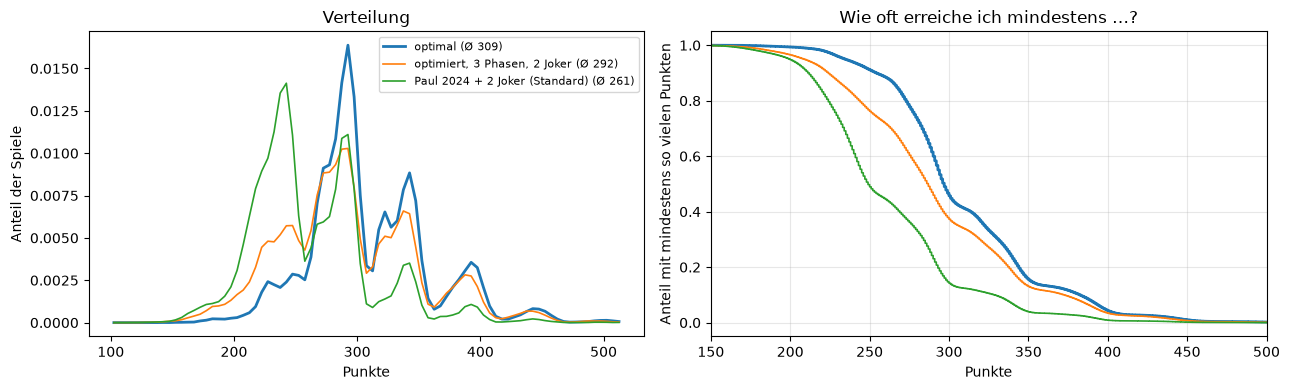

In [9]:
dist = B.verteilungen(joker=R.joker)
k = B.kennzahlen(dist)
display(k.style.format({c: "{:.1%}" for c in ["P(< 200)", "P(≥ 300)", "P(≥ 400)"]} | {c: "{:.1f}" for c in k.columns if not c.startswith("P(")}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
bins = np.arange(100, 520, 5)
for name, s in dist.items():
    h, e = np.histogram(s, bins=bins, density=True)
    a1.plot(e[:-1] + 2.5, h, lw=2 if name == "optimal" else 1.2, label=f"{name} (Ø {s.mean():.0f})")
    xs = np.sort(s)
    a2.plot(xs, 1 - np.arange(len(xs)) / len(xs), lw=2 if name == "optimal" else 1.2, label=name)
a1.set(xlabel="Punkte", ylabel="Anteil der Spiele", title="Verteilung")
a2.set(xlabel="Punkte", ylabel="Anteil mit mindestens so vielen Punkten", title="Wie oft erreiche ich mindestens …?", xlim=(150, 500))
a2.grid(alpha=0.3)
a1.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Wann lohnen sich Joker?

Für jeden möglichen Wurf nach dem dritten Wurf am Spielbeginn: Lohnt ein Joker, und welcher? Die Tabelle zeigt die Würfe, bei denen die optimale Strategie den Joker sofort einsetzt.

In [10]:
if R.joker:
    tt = S.turn()
    T = S.T
    rows = []
    for r in range(252):
        opt = tt["OPT3"][R.joker, r]
        if opt:
            wurf = "".join(str(v + 1) * T["roll_counts"][r][v] for v in range(6))
            art = "Neustart" if opt == 1 else f"eine {opt - 1} neu würfeln"
            rows.append((wurf, art, T["first"][r]))
    df = pd.DataFrame(rows, columns=["Wurf nach 3. Wurf", "Joker", "Häufigkeit als Erstwurf"])
    print(f"Am Spielbeginn setzt die optimale Strategie bei {len(df)} von 252 möglichen Endwürfen sofort einen Joker ein.")
    display(df.sort_values("Wurf nach 3. Wurf").head(30))
else:
    print("Joker sind ausgeschaltet (JOKER = 0).")

Am Spielbeginn setzt die optimale Strategie bei 72 von 252 möglichen Endwürfen sofort einen Joker ein.


,Wurf nach 3. Wurf,Joker,Häufigkeit als Erstwurf
0,11223,Neustart,0.003858
1,11224,Neustart,0.003858
2,11225,Neustart,0.003858
3,11226,Neustart,0.003858
4,11233,Neustart,0.003858
5,11235,Neustart,0.007716
6,11236,Neustart,0.007716
7,11244,Neustart,0.003858
8,11245,Neustart,0.007716
9,11246,Neustart,0.007716
